In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/cleaned_commodity_futures.csv")

# Feature Engineering

Feature engineering transforms raw financial time-series data into meaningful predictive indicators.

In this phase, we create:
- Daily returns
- Volatility indicators
- Moving averages
- Momentum signals
- Commodity risk metrics

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

In [5]:
df.head()

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,SOYBEAN MEAL,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,69.075,...,147.9,1215.00,67.78,8314.0,247.25,5.77,116.25,55.625,274.00,50.73
2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,68.975,...,150.7,1209.25,66.55,8307.0,249.75,5.81,118.60,55.075,276.25,51.56
2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,70.075,...,149.1,1212.00,66.28,8252.0,248.50,5.77,116.85,55.175,275.00,52.08
2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,70.875,...,149.1,1209.25,64.75,8174.0,251.75,5.84,114.15,55.625,277.75,53.96
2000-01-10,2.216,282.7,24.67,23.73,466.25,208.50,0.8465,5.190,196.00,70.775,...,147.7,1196.75,64.72,8130.0,253.50,5.83,117.55,55.650,279.75,53.56


In [6]:
returns_df = df.pct_change()

returns_df.dropna(inplace=True)

returns_df.head()

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,SOYBEAN MEAL,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-05,-0.003676,-0.005640,-0.025049,-0.027060,0.010770,0.000000,0.010024,-0.030698,-0.002342,-0.001448,...,0.018932,-0.004733,-0.018147,-0.000842,0.010111,0.006932,0.020215,-0.009888,0.008212,0.016361
2000-01-06,0.012915,0.001063,-0.005219,-0.004635,-0.002664,0.003695,-0.004086,-0.008253,-0.008216,0.015948,...,-0.010617,0.002274,-0.004057,-0.006621,-0.005005,-0.006885,-0.014755,0.001816,-0.004525,0.010085
2000-01-07,-0.010474,0.001771,-0.022599,-0.022439,0.007479,0.015951,0.001172,0.005419,-0.028402,0.011416,...,0.000000,-0.002269,-0.023084,-0.009452,0.013078,0.012132,-0.023107,0.008156,0.010000,0.036098
2000-01-10,0.019788,-0.000707,0.018580,0.027718,-0.011135,0.007246,-0.008782,-0.000962,-0.045067,-0.001411,...,-0.009390,-0.010337,-0.000463,-0.005383,0.006951,-0.001712,0.029785,0.000449,0.007201,-0.007413
2000-01-11,0.019856,0.006013,0.044589,0.037505,0.001609,-0.005995,-0.003544,0.000963,0.028061,0.001413,...,0.007448,-0.009818,0.031366,-0.009533,0.000986,-0.027444,0.002127,0.006739,0.000894,0.011576


In [7]:
volatility_df = returns_df.rolling(window=30).std()

In [8]:
risk_scores = volatility_df * 100

In [9]:
latest_risk = risk_scores.iloc[-1]

latest_risk.sort_values(ascending=False)

CORN                   4.608082
WHEAT                  3.513028
NATURAL GAS            3.481609
SOYBEAN OIL            3.047814
HRW WHEAT              2.932105
NICKEL                 2.289371
ZINC                   1.982248
LOW SULPHUR GAS OIL    1.948739
COTTON                 1.845614
COFFEE                 1.737737
LEAN HOGS              1.696243
SOYBEANS               1.695465
WTI CRUDE              1.585314
SILVER                 1.576490
SUGAR                  1.563051
ULS DIESEL             1.500920
ALUMINIUM              1.471698
BRENT CRUDE            1.403468
SOYBEAN MEAL           1.338344
COPPER                 1.320458
LIVE CATTLE            0.682401
GOLD                   0.618167
Name: 2023-08-04 00:00:00, dtype: float64

In [10]:
top_risk = latest_risk.sort_values(ascending=False).head(10)

top_risk

CORN                   4.608082
WHEAT                  3.513028
NATURAL GAS            3.481609
SOYBEAN OIL            3.047814
HRW WHEAT              2.932105
NICKEL                 2.289371
ZINC                   1.982248
LOW SULPHUR GAS OIL    1.948739
COTTON                 1.845614
COFFEE                 1.737737
Name: 2023-08-04 00:00:00, dtype: float64

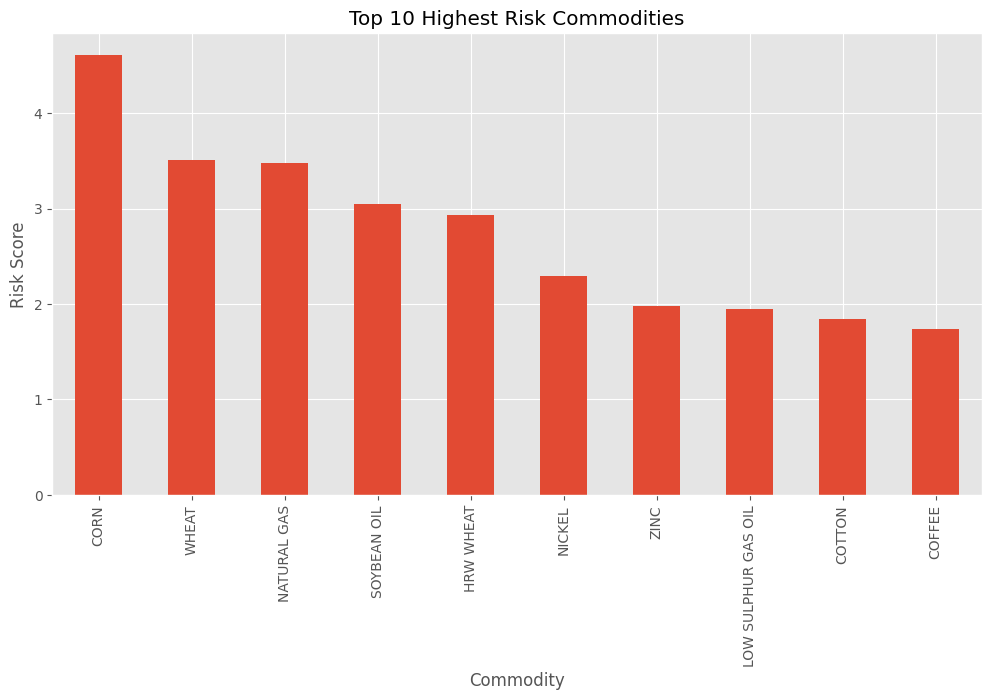

In [11]:
plt.figure(figsize=(12,6))

top_risk.plot(kind='bar')

plt.title("Top 10 Highest Risk Commodities")
plt.xlabel("Commodity")
plt.ylabel("Risk Score")

plt.show()

## Gold Moving Averages

In [12]:
df['GOLD_MA30'] = df['GOLD'].rolling(window=30).mean()

df['GOLD_MA90'] = df['GOLD'].rolling(window=90).mean()

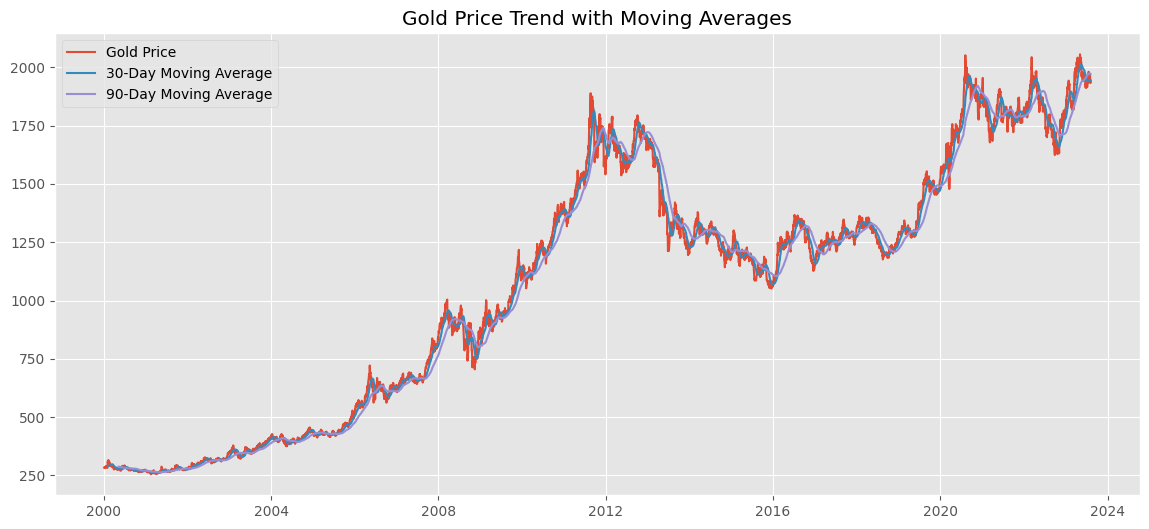

In [13]:
plt.figure(figsize=(14,6))

plt.plot(df['GOLD'], label='Gold Price')

plt.plot(df['GOLD_MA30'], label='30-Day Moving Average')

plt.plot(df['GOLD_MA90'], label='90-Day Moving Average')

plt.legend()

plt.title("Gold Price Trend with Moving Averages")

plt.show()

## Correlation of Returns

In [14]:
returns_corr = returns_df.corr()

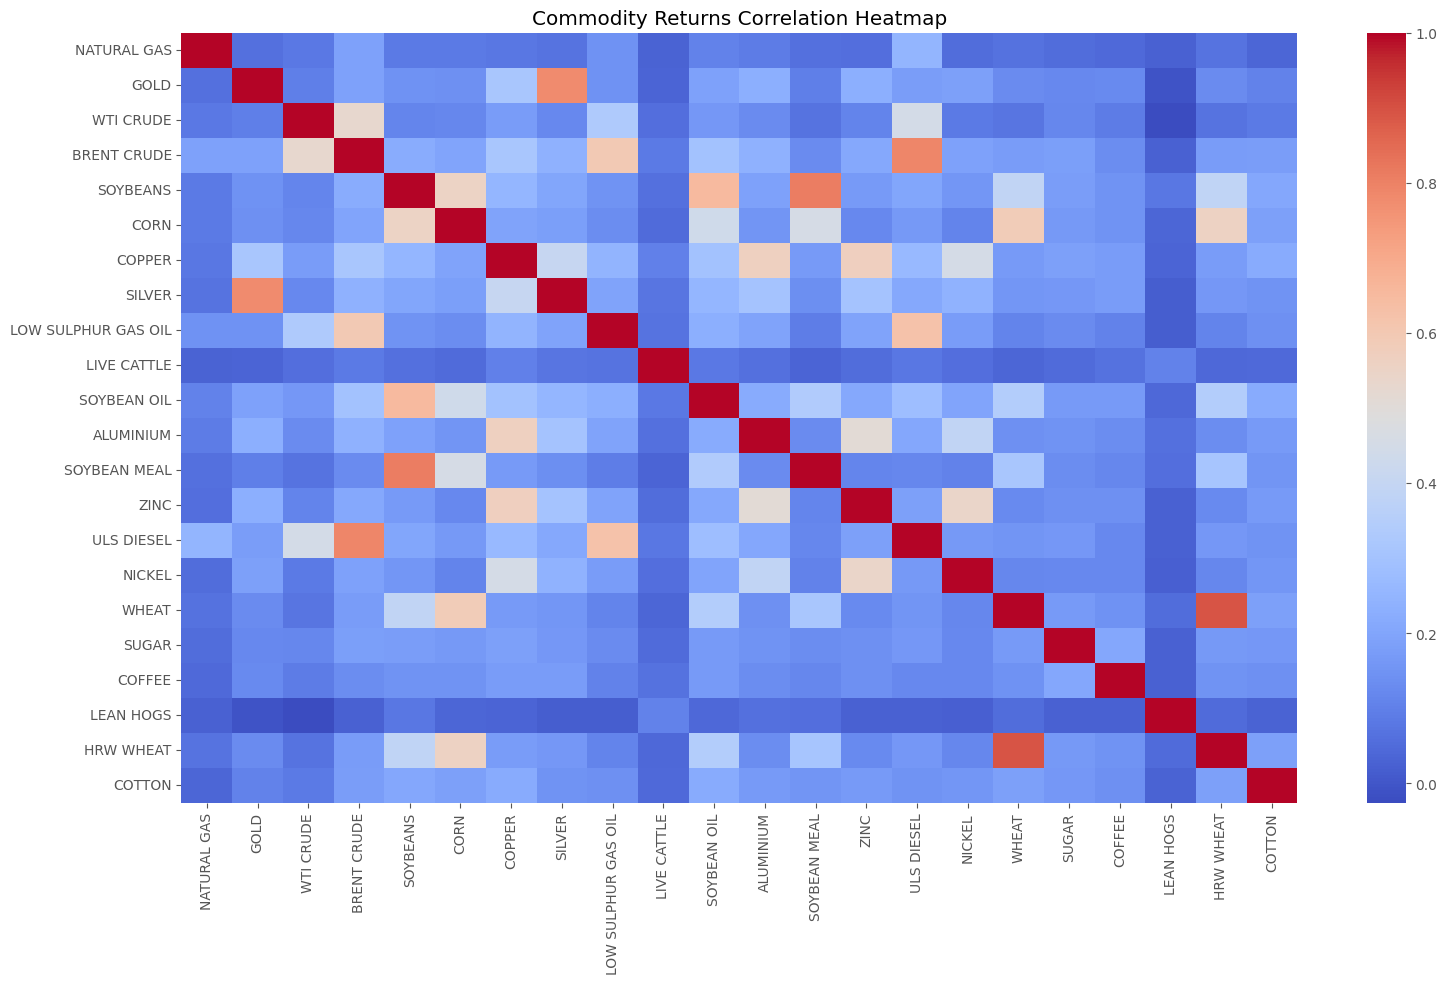

In [15]:
plt.figure(figsize=(18,10))

sns.heatmap(returns_corr, cmap='coolwarm')

plt.title("Commodity Returns Correlation Heatmap")

plt.show()

In [16]:
%cd

/Users/karanmac


/Users/karanmac/Desktop/Repo/matrisk-ai/venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/Users/karanmac/Desktop/Repo/matrisk-ai/venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [17]:
cd

/Users/karanmac


/Users/karanmac/Desktop/Repo/matrisk-ai/venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/Users/karanmac/Desktop/Repo/matrisk-ai/venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [18]:
%pwd

'/Users/karanmac'

In [23]:
import os

os.getcwd()

'/Users/karanmac'

In [24]:
returns_df.to_csv("/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/daily_returns.csv")

In [25]:
volatility_df.to_csv("/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/volatility.csv")

In [26]:
risk_scores.to_csv("/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/risk_scores.csv")